## Utilities

Libraries

In [1]:
# data manipulation
import numpy as np
import pandas as pd
import networkx as nx
from typing import List, Tuple, Dict, Sequence, Union, Optional, Any
from math import comb, gamma, log
from scipy.special import digamma
import matplotlib.pyplot as plt
import itertools
from itertools import combinations
import random
from tqdm import tqdm

# data preprocessing
from sklearn.preprocessing import StandardScaler

# mutual information
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed

# classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score
import shap

# qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeTorino, FakeVigoV2
from qiskit_aer.noise import NoiseModel, QuantumError, depolarizing_error, ReadoutError
from qiskit.quantum_info import SuperOp, Kraus

# saving and loading
import json
import os

IBM account loading

In [37]:
service = QiskitRuntimeService()
BACKEND = service.backend("ibm_marrakesh")

management.get:WARNING:2026-01-28 10:22:34,908: Loading default saved account


## Hyperparameters

In [29]:
# Trotterization and time parametes
N_TROTTER_STEPS = 1
DELTA_T = 0.005
T = N_TROTTER_STEPS * DELTA_T
ORDER=2
REPS=1

# stratified k-fold parameters
N_SPLITS = 2
N_REPEATS = 2

# shap parameters
NUM_FEATURES_SHAP = 50
SHAP_THRESHOLD=2.0

# circuit parameters
SEED = 42
OPTIMIZATION_LEVEL = 3
NUM_QUBITS = 60

# combinations parameters
Q_KS_FOR_AUG = [1,2]
K_MAX=2

# quantum feature map parameters
GAMMA_Q = 1.0
RHO_THRESHOLD = 0.0

# settings for saving/loading quantum features
FROM_DIR = True
DIR_PATH = "C:/Users/jiriv/Documents/škola/Diplom_thesis/Quantum-feature-maps/QFM_approach/results/fez_60qubits/"
USE_QPU = True

# quantum blocks parameters (if used)
NUM_BLOCKS = 15
MIN_BLOCK_SIZE = 10

## Dataset

In [4]:
def load_dataset(dataset_dir):
    df = pd.read_csv(dataset_dir)
    df['Class'] = df['Class'].map({'NonToxic': 1,'Toxic': 0})
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

# feature reduction to match number of qubits in qpu
def reduce_features(X, y, n_features):
    if X.shape[1] <= n_features:
        return X
    else:
        mi = mutual_info_classif(X, y, n_neighbors=5, discrete_features=False, random_state=SEED)
        mi_indices = np.argsort(mi)[-n_features:]
        return X[:, mi_indices]

def data_preprocessing(X_train, X_test):
    scaler = StandardScaler() # Rescale the data using z-score: (x - μ (mean))/μ (standard deviation)
    X_tr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)
    return X_tr, Xte

In [5]:
path = "C:/Users/jiriv/Documents/škola/Diplom_thesis/Quantum-feature-maps/Dataset/data.csv"
X_raw, y_raw = load_dataset(path)
print(X_raw.shape, y_raw.shape)
X_reduced = reduce_features(X_raw, y_raw, NUM_QUBITS)
print(X_reduced.shape)

(171, 1203) (171,)
(171, 60)


## Mutual information calculation

In [6]:
def calculate_MI_matrix(X):
    num_features = X.shape[1]
    MI = np.zeros((num_features, num_features))
    for i in range(num_features):
        for j in range(i+1, num_features):
            MI[i, j] = mutual_info_regression(
                X[:, [i]],
                X[:, j],
                random_state=SEED
            )[0]
            MI[j, i] = MI[i, j]

    MI_norm = MI / (MI.max() + 1e-12)
    return MI_norm

# doublets
def calculate_Jij_dict(X):
    MI_norm = calculate_MI_matrix(X)
    Jij_dict = {}
    num_features = X.shape[1]
    for i in range(num_features):
        for j in range(i+1, num_features):
            Jij_dict[(i, j)] = MI_norm[i, j]
    return Jij_dict

# triplets
# article: the three-body term Jijk is approximated using the average of the corresponding pairwise mutual information values
# Jijk = (Jij + Jik + Jjk) / 3
def calculate_Jijk_dict(X):
    MI_norm = calculate_MI_matrix(X)
    num_features = X.shape[1]

    Jijk_dict = {}
    for i in range(num_features):
        for j in range(i + 1, num_features):
            for k in range(j + 1, num_features):
                Jijk_dict[(i, j, k)] = (MI_norm[i, j] + MI_norm[i, k] + MI_norm[j, k]) / 3.0
    return Jijk_dict

def create_combinations(X):
    num_features = X.shape[1]
    MI_matrix = calculate_MI_matrix(X)
    combinations = [(i, j) for i in range(num_features) for j in range(i+1, num_features) if MI_matrix[i, j] >= RHO_THRESHOLD]
    return combinations

def create_triplet_combinations(X):
    Jijk_dict = calculate_Jijk_dict(X)
    triplets = [(i, j, k) for (i, j, k), val in Jijk_dict.items() if val >= RHO_THRESHOLD]
    return triplets

## Genetic algorithm for optimal feature to qubit assignment
 - based on Appendix A of Digitized Counterdiabatic Quantum Feature Extraction

In [7]:
def adjacency_matrix(num_qubits, edges):
    A = np.zeros((num_qubits, num_qubits))
    for q1, q2 in edges:
        A[q1, q2] = 1
        A[q2, q1] = 1
    return A

def fitness(chromosome, Jij_dict, A):
    score = 0.0
    for (i, j), Jij in Jij_dict.items():
        qi = chromosome[i]
        qj = chromosome[j]
        score += Jij * A[qi, qj]
    return score

def init_population(pop_size, num_features):
    return [random.sample(range(num_features), num_features) for _ in range(pop_size)]

def order_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1] * n
    child[a:b] = p1[a:b]

    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def swap_mutation(chromosome, mutation_rate=0.1):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(chromosome)), 2)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
    return chromosome

def tournament_selection(population, fitnesses, k=3):
    selected = random.sample(list(zip(population, fitnesses)), k)
    return max(selected, key=lambda x: x[1])[0]

def order_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1] * n
    child[a:b] = p1[a:b]

    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def swap_mutation(chromosome, mutation_rate=0.1):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(chromosome)), 2)
        chromosome[i], chromosome[j] = chromosome[j], chromosome[i]
    return chromosome

def genetic_feature_to_qubit_mapping(
    Jij_dict,
    qubit_edges,
    num_features,
    pop_size=100,
    generations=200,
    mutation_rate=0.1,
    seed=SEED
):
    random.seed(seed)
    np.random.seed(seed)

    # Determine number of qubits from the device edges
    num_qubits = max(max(e) for e in qubit_edges) + 1
    A = adjacency_matrix(num_qubits, qubit_edges)

    population = init_population(pop_size, num_features)

    best_solution = None
    best_score = -np.inf
    history = []

    for gen in range(generations):
        fitnesses = [fitness(ch, Jij_dict, A) for ch in population]

        idx = np.argmax(fitnesses)
        if fitnesses[idx] > best_score:
            best_score = fitnesses[idx]
            best_solution = population[idx]

        history.append(best_score)

        new_population = []
        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)

            child = order_crossover(p1, p2)
            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population
        if (gen + 1) % 10 == 0 or gen == 0:
            print(f"Generation {gen+1}/{generations}, Best Fitness: {best_score:.4f}")

    return best_solution, best_score, history

def plot_ga_convergence(history):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best fitness")
    plt.title("Genetic Algorithm Convergence")
    plt.grid(True)
    plt.show()

 - plotting of qubit map

In [8]:
def mapped_edge_weights(best_map, Jij_dict, qubit_edges):
    """
    Returns dictionary {(q1,q2): weight}
    """
    # inverse map: qubit -> feature
    inv_map = {q: f for f, q in enumerate(best_map)}

    weights = {}
    for q1, q2 in qubit_edges:
        if q1 in inv_map and q2 in inv_map:
            f1 = inv_map[q1]
            f2 = inv_map[q2]
            weights[(q1, q2)] = Jij_dict.get(
                tuple(sorted((f1, f2))), 0.0
            )
        else:
            weights[(q1, q2)] = 0.0

    return weights

def plot_heavy_hex_mapping(
    qubit_edges,
    edge_weights,
    best_map=None,       # list mapping features -> qubits
    node_positions=None,
    title="Feature–Qubit Coupling Map"
):
    G = nx.Graph()
    G.add_edges_from(qubit_edges)

    # Default layout if none provided
    if node_positions is None:
        #pos = nx.spring_layout(G, seed=42)
        #pos = nx.spring_layout(G, seed=SEED, k=2.5 / np.sqrt(len(G.nodes())), iterations=300)
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = node_positions

    # Determine which qubits are used
    used_qubits = set(best_map) if best_map is not None else set()

    # Node colors
    node_colors = ["blue" if n in used_qubits else "lightgray" for n in G.nodes()]

    weights = np.array(list(edge_weights.values()))
    max_w = weights.max() if weights.max() > 0 else 1.0

    fig, ax = plt.subplots(figsize=(20, 10))

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=450,
        node_color=node_colors,
        ax=ax
    )

    # Draw labels
    nx.draw_networkx_labels(
        G, pos,
        font_color="white",
        font_size=8,
        ax=ax
    )

    # Draw edges with weighted coloring; edges with unused qubits are faint
    for (edge, w) in edge_weights.items():
        q1, q2 = edge
        if q1 in used_qubits and q2 in used_qubits:
            color = [w]  # use MI color
            width = 1 + 5 * (w / max_w)
        else:
            color = ["lightgray"]  # faint for unused edges
            width = 1.0
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[edge],
            width=width,
            edge_color=color,
            edge_cmap=plt.cm.viridis if q1 in used_qubits and q2 in used_qubits else None,
            edge_vmin=0,
            edge_vmax=max_w,
            ax=ax
        )

    # Colorbar only for edges between used qubits
    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.viridis,
        norm=plt.Normalize(vmin=0, vmax=max_w)
    )
    sm.set_array([])  # required
    plt.colorbar(sm, ax=ax, label="Normalized Mutual Information")

    ax.set_title(title)
    ax.axis("off")
    plt.show()

Generation 1/300, Best Fitness: 6.6011
Generation 10/300, Best Fitness: 7.8466
Generation 20/300, Best Fitness: 7.8466
Generation 30/300, Best Fitness: 7.8466
Generation 40/300, Best Fitness: 7.8802
Generation 50/300, Best Fitness: 7.9385
Generation 60/300, Best Fitness: 8.4245
Generation 70/300, Best Fitness: 8.4245
Generation 80/300, Best Fitness: 8.4245
Generation 90/300, Best Fitness: 8.4511
Generation 100/300, Best Fitness: 8.4511
Generation 110/300, Best Fitness: 8.7152
Generation 120/300, Best Fitness: 8.8847
Generation 130/300, Best Fitness: 9.1653
Generation 140/300, Best Fitness: 9.1653
Generation 150/300, Best Fitness: 9.1653
Generation 160/300, Best Fitness: 9.3495
Generation 170/300, Best Fitness: 9.3495
Generation 180/300, Best Fitness: 9.3495
Generation 190/300, Best Fitness: 9.7449
Generation 200/300, Best Fitness: 9.7449
Generation 210/300, Best Fitness: 9.7449
Generation 220/300, Best Fitness: 9.7449
Generation 230/300, Best Fitness: 9.7449
Generation 240/300, Best Fi

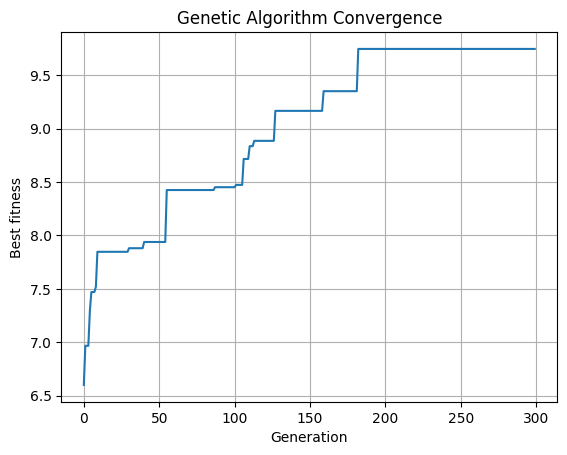

In [11]:
backend = BACKEND
coupling_map = backend.target.build_coupling_map()
device_edges = list(coupling_map.get_edges())
X = X_reduced 
best_map, best_score, history = genetic_feature_to_qubit_mapping(
    Jij_dict=calculate_Jij_dict(X),
    qubit_edges=device_edges,
    num_features=X.shape[1],
    pop_size=100,
    generations=300,
    mutation_rate=0.12,
    seed=42
)

print("Best mapping:", best_map)
print("Best score:", best_score)

plot_ga_convergence(history)

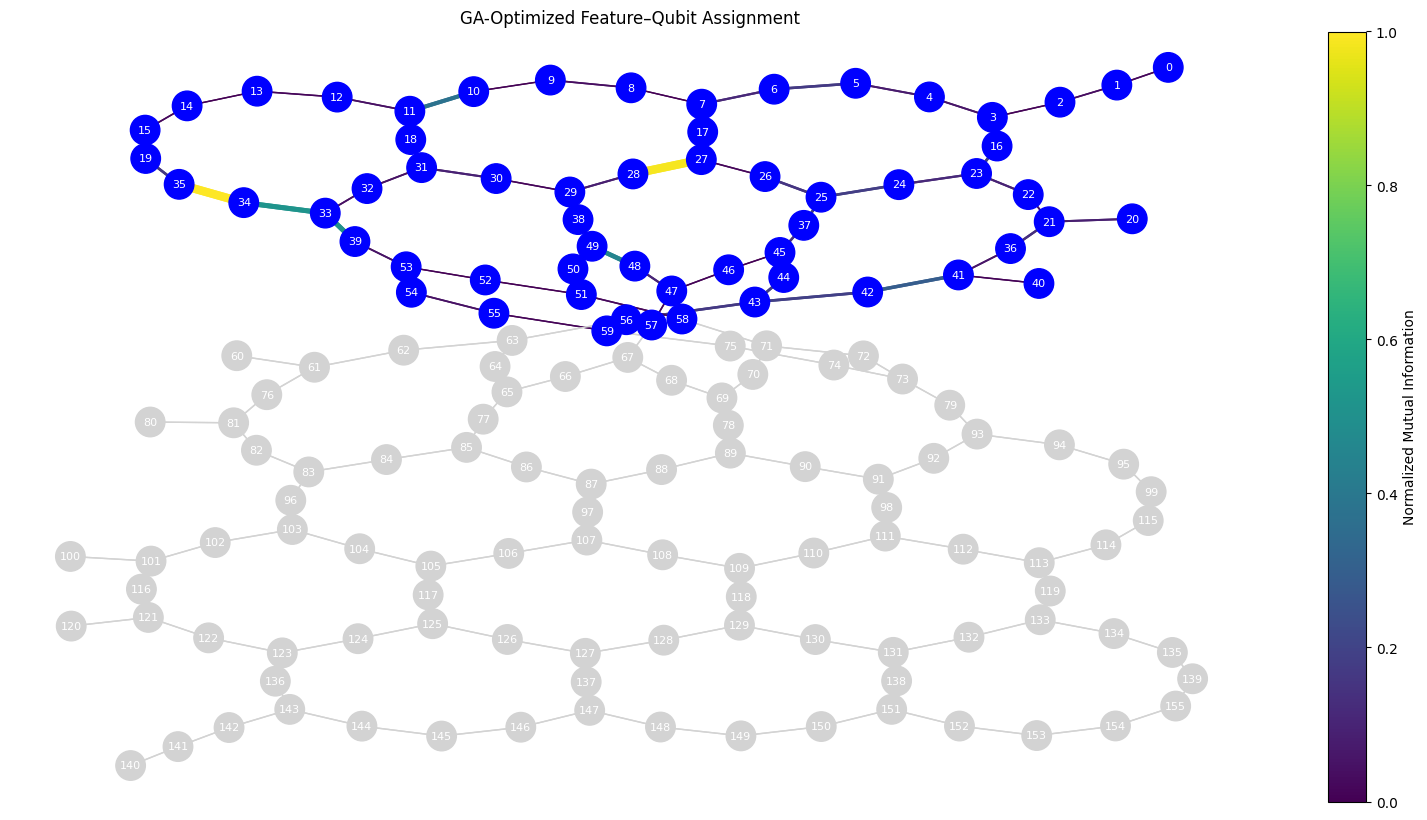

In [12]:
edge_weights = mapped_edge_weights(
    best_map=best_map,
    Jij_dict=calculate_Jij_dict(X),
    qubit_edges=device_edges
)

plot_heavy_hex_mapping(
    qubit_edges=device_edges,
    edge_weights=edge_weights,
    best_map=best_map,
    title="GA-Optimized Feature–Qubit Assignment"
)


In [13]:
MAP = best_map

# create file and save the mapping
with open("best_map_156qubits.json", "w") as f:
    json.dump(MAP, f)

## Circuit construction

Alpha calculation

In [14]:
def makeRt(h_x, J_dict, s, sum_hi2, sum_Jij2):
    sum_hi4 = 0
    sum_Jij4 = 0

    for hi in h_x:
        sum_hi4 += hi**4

    for (i,j), Jij in J_dict.items():
        sum_Jij4 += Jij**4

    N = len(h_x)  

    sum_hi2Jii2 = 0
    for (i,j), Jij in J_dict.items():  #i<j
        hi = h_x[i]
        hj = h_x[j]
        sum_hi2Jii2 += (hi**2 + hj**2)*(Jij**2)

    contrib_duplet = 2 * 6 * sum_hi2Jii2  # pois i<>j

    sum_triplet = 0.0
    for i, j, k in combinations(range(N), 3):  # i<j<k
        if ((i, j) not in J_dict or (i, k) not in J_dict or (j, k) not in J_dict):
            continue

        Jij = J_dict[(i, j)]
        Jik = J_dict[(i, k)]
        Jjk = J_dict[(j, k)]

        sum_triplet += (Jij**2 * Jik**2 +
                        Jij**2 * Jjk**2 +
                        Jik**2 * Jjk**2)

    
    contrib_triplet = 6.0 * sum_triplet  # i<j<k

    Rt = ((1 - s)**2)*(sum_hi2 + 4*sum_Jij2) + (s**2)*(sum_hi4 + 2*sum_Jij4 + contrib_duplet + contrib_triplet)
    # Rt = ((1 - s)**2)*(sum_hi2 + 4*sum_Jij2) + (s**2)*(sum_hi4 + sum_Jij4 + contrib_duplet + contrib_triplet)

    return Rt

def makeAlpha1(h_x, J_dict, s):
    sum_hi2 = 0
    sum_Jij2 = 0

    for hi in h_x:
        sum_hi2 += hi**2

    for (i,j), Jij in J_dict.items():
        sum_Jij2 += Jij**2

    alpha1 = -(1/4)*(sum_hi2 + 2*sum_Jij2) # aqui tem um fator 2 que falta no paper porque o correto é \sum_{i<>j} e não \sum_{i<j}
    Rt = makeRt(h_x, J_dict, s, sum_hi2, 2*sum_Jij2)
    alpha1 = alpha1/Rt

    return alpha1

H counterdiabatic

In [15]:
def make_Hcd(h_x, J_dict, s, ds):
    n = len(h_x)
    terms_HP = []
    for i, hi in enumerate(h_x):
        if hi != 0: terms_HP.append(("I"*i + "Y" + "I"*(n-i-1), float(hi)))

    for (i,j), Jij in J_dict.items():
        YZ = ["I"]*n 
        ZY = ["I"]*n 
        YZ[i]= 'Y'
        YZ[j]= 'Z'
        ZY[i]= 'Z'
        ZY[j]= 'Y'        
        terms_HP.append(("".join(YZ), float(Jij)))
        terms_HP.append(("".join(ZY), float(Jij)))
    alpha1 = makeAlpha1(h_x, J_dict, s)
    Hcd = SparsePauliOp.from_list(terms_HP) * -2*ds*alpha1
    return Hcd


def ds_curve(t, T):
    s = t/T
    D = ((np.pi**2)/(4*T))*np.sin(np.pi*s)*np.sin(np.pi*(np.sin((np.pi/2)*s)**2))
    return D

def s_curve(t_norm):
    return np.sin(0.5*np.pi * np.sin(0.5*np.pi * t_norm)**2)**2

def build_circuit(h_x, J_dict, T, order, reps, insert_barriers=False, preserve_order=True):
    n = len(h_x)

    qc = QuantumCircuit(n)
    qc.h(range(n))

    synth = SuzukiTrotter(order=order, reps=reps, insert_barriers=insert_barriers, preserve_order=preserve_order)
    
    t_mid = 0.25*DELTA_T
    s = s_curve(t_mid/DELTA_T)
    ds = ds_curve(t_mid, DELTA_T)
        
    H_cd = make_Hcd(h_x, J_dict, s, ds)

    qc.append(PauliEvolutionGate(H_cd, time=DELTA_T, synthesis=synth), range(n))
    return qc


Observables

In [16]:
def Z_observables(n, k_max):
    obs = []
    # one qubit Z
    for i in range(n):
        obs.append(SparsePauliOp.from_list([( "I"*i + "Z" + "I"*(n-i-1), 1.0 )]))
    # two qubit Z
    for k in range(2, k_max+1):
        for idx in combinations(range(n), k):
            p = ["I"]*n
            for j in idx: p[j]="Z"
            obs.append(SparsePauliOp.from_list([("".join(p), 1.0)]))
    return obs

Noise analysis on few qubits (<=10 qubits)

Noise model

In [17]:
def dephasing_kraus(p):
    K0 = np.sqrt(1 - p) * np.eye(2)
    K1 = np.sqrt(p) * np.array([[1, 0], [0, -1]])
    return [K0, K1]

def amplitude_damping_kraus(gamma):
    K0 = np.array([[1, 0], [0, np.sqrt(1 - gamma)]])
    K1 = np.array([[0, np.sqrt(gamma)], [0, 0]])
    return [K0, K1]

def noise_model(p, p_):
    noise_model = NoiseModel()
    # --- Kraus noise ---
    cx_depolarizing_prob = p
    bit_flip_prob = p_

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
    depolarizing_error(cx_depolarizing_prob, 2), ["cx"])
    noise_model.add_all_qubit_readout_error(
        ReadoutError(
            [
                [1 - bit_flip_prob, bit_flip_prob],
                [bit_flip_prob, 1 - bit_flip_prob],
            ]
        )
    )
    """
    E1 = Kraus(dephasing_kraus(p))

    # 2-qubit dephasing = tensor product
    E2 = E1.tensor(E1)

    for gate in ['rz', 'rx', 'ry']:
        noise_model.add_all_qubit_quantum_error(E1, gate)

    # 2-qubit gates
    noise_model.add_all_qubit_quantum_error(E2, 'cx')
    """

    return noise_model

Remaping features to physical qubits

In [18]:
def remap_fields(x_row, map, num_qubits):
    h_qubit = np.zeros(num_qubits)
    for i, q in enumerate(map):
        h_qubit[q] = x_row[i]
    return h_qubit

def remap_couplings(rho_ff, pairs, map):
    J_ij_qubit = {}
    for (i, j) in pairs:
        qi = map[i]
        qj = map[j]
        J_ij_qubit[(qi, qj)] = float(rho_ff[i, j])
    return J_ij_qubit

Feature extraction

In [38]:
def build_q_feature_circuit(x_row, rho_ff, pairs, tau, order=ORDER, reps=REPS, k_max=K_MAX, use_qpu=USE_QPU):
    n = len(x_row)

    if use_qpu:
        # remap fields and couplings
        h_vec = remap_fields(x_row, MAP, n)
        J_dict = remap_couplings(rho_ff, pairs, MAP)
    else:
        h_vec = np.asarray(x_row, float)
        J_dict = {(i, j): float(rho_ff[i, j]) for (i, j) in pairs}


    qc = build_circuit(h_vec, J_dict, tau, order=order, reps=reps)
    obs_list = Z_observables(n, k_max)

    return qc, obs_list

def q_feature_matrix(X, rho_ff, pairs, tau, order=ORDER, reps=REPS, k_max=K_MAX, use_qpu=USE_QPU, desc="qmap"):
    if use_qpu == True:
        backend = BACKEND
        
        # ----estimator setup-----
        estimator = Estimator(mode=backend)

        # error mitigation options
        #estimator.options.twirling.enable_gates = True
        #estimator.options.twirling.num_randomizations = 480
        #estimator.options.twirling.shots_per_randomization = 400

        #estimator.options.resilience.measure_mitigation = True
        #estimator.options.resilience.measure_noise_learning.num_randomizations = 480
        #estimator.options.resilience.measure_noise_learning.shots_per_randomization = 400

        # transpilation setup
        pm = generate_preset_pass_manager(backend=backend, optimization_level=OPTIMIZATION_LEVEL)
    else:
        #noise_model_instance = noise_model(p=0.02, p_=0.05)
        #backend = AerSimulator(method="density_matrix", device="CPU", noise_model=noise_model_instance)
        backend = AerSimulator(method="statevector", device="CPU")
        #backend = FakeTorino()
        
        # ----estimator setup-----
        backend.options.seed_simulator = SEED
        backend.options.seed_transpiler = SEED
        estimator = Estimator(mode=backend)
        
        # transpilation setup
        pm = generate_preset_pass_manager(backend=backend, optimization_level=OPTIMIZATION_LEVEL)
        
    # -------------------------
    # Build all circuits
    # -------------------------
    pubs = []

    for row in tqdm(X, desc=desc, leave=True):
        # build circuit + observables
        qc, obs = build_q_feature_circuit(row, rho_ff, pairs, tau, order, reps, k_max, use_qpu)
        # transpile + apply layout
        isa_circuit = pm.run(qc)
        isa_obs = [o.apply_layout(isa_circuit.layout) for o in obs]
        pubs.append((isa_circuit, isa_obs))

    # run all circuits in a single job
    print("Submitting job to backend...")
    job = estimator.run(pubs)

    if use_qpu == True:
        #with open(f'{DIR_PATH}/job_id.txt', 'w') as file:
        #    file.write(job.job_id())
        print(job.job_id())
        print(job.status())

    print("Waiting for job to complete...")
    job_result = job.result()

    # extract all expectation values
    q_features = []
    for idx in range(len(pubs)):
        expvals = job_result[idx].data.evs
        expvals = np.asarray(expvals, dtype=np.float64)
        q_features.append(np.asarray(expvals, dtype=np.float64))

    return np.vstack(q_features)

## Classification

### - classical approach

In [20]:
def classification(X, y):
    rscv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    metrics = {
        'AUC': [],
        'F1 Macro': [],
        'Precision Macro': [],
        'Recall Macro': [],
        'Accuracy': []
    }
    for fold, (train_id, test_id) in enumerate(rscv.split(X,y)):
        print(f"Fold number: {fold+1}")

        x_train = X[train_id]
        x_test = X[test_id]
        y_train = y[train_id]
        y_test = y[test_id]

        x_train, x_test = data_preprocessing(x_train, x_test)
        classifier = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        classifier.fit(x_train, y_train)

        y_pred = classifier.predict(x_test)
        y_proba = classifier.predict_proba(x_test)[:, 1]

        metrics['AUC'].append(roc_auc_score(y_test, y_proba))
        metrics['F1 Macro'].append(f1_score(y_test, y_pred, average='macro'))
        metrics['Precision Macro'].append(precision_score(y_test, y_pred, average='macro'))
        metrics['Recall Macro'].append(recall_score(y_test, y_pred, average='macro'))
        metrics['Accuracy'].append(accuracy_score(y_test, y_pred))    

    median_metrics = {k: np.median(v) for k, v in metrics.items()}

    return median_metrics

### - run just the augmentation (on QPU)

In [30]:
def run_augmentation(X, y, save_dir):

    os.makedirs(save_dir, exist_ok=False)

    rscv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
    for fold, (train_id, test_id) in enumerate(rscv.split(X,y)):
        print(f"Fold number: {fold+1}")

        x_train = X[train_id]
        x_test = X[test_id]
        y_train = y[train_id]
        y_test = y[test_id]

        x_train, x_test = data_preprocessing(x_train, x_test)

        # Prepare quantum feature map parameters
        pairs = create_combinations(x_train)
        rho_ff = calculate_MI_matrix(x_train)
        
        # Generate quantum features
        x_tilde_train = q_feature_matrix(x_train, rho_ff, pairs, DELTA_T)
        x_tilde_test = q_feature_matrix(x_test, rho_ff, pairs, DELTA_T)

        save_path = os.path.join(save_dir, f"fold_{fold}.npz")
        np.savez_compressed(
            save_path,
            x_tilde_train=x_tilde_train,
            x_tilde_test=x_tilde_test,
            pairs=pairs,
            rho_ff=rho_ff,
            train_id=train_id,
            test_id=test_id,
            y_train=y_train,
            y_test=y_test
        )

    print(f" Quantum features saved in: {save_dir}")

def load_quantum_features(save_dir, fold):
    data = np.load(
        os.path.join(save_dir, f"fold_{fold}.npz"),
        allow_pickle=True
    )

    return (
        data["x_tilde_train"],
        data["x_tilde_test"],
        data["pairs"],
        data["rho_ff"],
        #data["y_train"],
        #data["y_test"],
    )

### - quantum approach

In [22]:
def initialize_metrics():
    return {
        'AUC': [],
        'F1 Macro': [],
        'Precision Macro': [],
        'Recall Macro': [],
        'Accuracy': []
    }

def classification_quantum(X, y, from_dir=FROM_DIR, k_max=K_MAX):
    rscv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    metrics_q = initialize_metrics()
    metrics_q_by_k = {k: initialize_metrics() for k in range(1, k_max + 1)}
    metrics_c = initialize_metrics()
    shap50_metrics = initialize_metrics()
    metrics_cl_shap = initialize_metrics()

    shap_rankings = []

    for fold, (train_id, test_id) in enumerate(rscv.split(X,y)):
        print(f"Fold number: {fold+1}")

        x_train = X[train_id]
        x_test = X[test_id]
        y_train = y[train_id]
        y_test = y[test_id]

        x_train, x_test = data_preprocessing(x_train, x_test)

        # =========================
        # Classical baseline
        # =========================
        clf_c = GradientBoostingClassifier(
            n_estimators=1000,
            random_state=SEED
        )
        clf_c.fit(x_train, y_train)

        y_pred_c = clf_c.predict(x_test)
        y_proba_c = clf_c.predict_proba(x_test)[:, 1]

        metrics_c['AUC'].append(roc_auc_score(y_test, y_proba_c))
        metrics_c['F1 Macro'].append(f1_score(y_test, y_pred_c, average='macro'))
        metrics_c['Precision Macro'].append(precision_score(y_test, y_pred_c, average='macro', zero_division=0))
        metrics_c['Recall Macro'].append(recall_score(y_test, y_pred_c, average='macro'))
        metrics_c['Accuracy'].append(accuracy_score(y_test, y_pred_c))

        # =========================
        # Quantum feature pipeline
        # =========================

        if from_dir == True:
            x_tilde_train, x_tilde_test, pairs, rho_ff = load_quantum_features(save_dir=DIR_PATH, fold=fold)
        else:
            pairs = create_combinations(x_train)
            rho_ff = calculate_MI_matrix(x_train)

            x_tilde_train = q_feature_matrix(x_train, rho_ff, pairs, DELTA_T)
            x_tilde_test = q_feature_matrix(x_test, rho_ff, pairs, DELTA_T)

        # -----Split quantum features by k-----
        n_qubits = x_train.shape[1]
        k_max_eff = min(k_max, n_qubits)

        # Number of features per k
        sizes_by_k = {k: comb(n_qubits, k) for k in range(1, k_max_eff + 1)}

        Xq_train_by_k = {}
        Xq_test_by_k  = {}

        offset = 0
        for k in range(1, k_max_eff + 1):
            size_k = sizes_by_k[k]
            Xq_train_by_k[k] = x_tilde_train[:, offset:offset + size_k]
            Xq_test_by_k[k]  = x_tilde_test[:,  offset:offset + size_k]
            offset += size_k
        # ----end of splitting quantum features by k-----

        classifier = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        classifier.fit(x_tilde_train, y_train)

        y_pred = classifier.predict(x_tilde_test)
        y_proba = classifier.predict_proba(x_tilde_test)[:, 1]

        metrics_q['AUC'].append(roc_auc_score(y_test, y_proba))
        metrics_q['F1 Macro'].append(f1_score(y_test, y_pred, average='macro'))
        metrics_q['Precision Macro'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics_q['Recall Macro'].append(recall_score(y_test, y_pred, average='macro'))
        metrics_q['Accuracy'].append(accuracy_score(y_test, y_pred))

        # ========================
        # Quantum features by k
        # ========================
        for k in range(1, k_max_eff + 1):
            model_k = GradientBoostingClassifier(
                n_estimators=1000,
                random_state=SEED
            )
            model_k.fit(Xq_train_by_k[k], y_train)

            y_pred_k = model_k.predict(Xq_test_by_k[k])
            y_proba_k = model_k.predict_proba(Xq_test_by_k[k])[:, 1]

            metrics_q_by_k[k]['AUC'].append(roc_auc_score(y_test, y_proba_k))
            metrics_q_by_k[k]['F1 Macro'].append(f1_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Precision Macro'].append(precision_score(y_test, y_pred_k, average='macro', zero_division=0))
            metrics_q_by_k[k]['Recall Macro'].append(recall_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Accuracy'].append(accuracy_score(y_test, y_pred_k))

        # =========================
        # SHAP on classical + quantum features
        # =========================

        # Augmented features =  classical + quantum features
        x_aug_train = np.hstack([x_train, GAMMA_Q * x_tilde_train]).astype(np.float32)
        x_aug_test  = np.hstack([x_test,  GAMMA_Q * x_tilde_test ]).astype(np.float32)

        # ----- Feature names -----
        n_cl = x_train.shape[1]
        cl_names = [f"cl_{j}" for j in range(n_cl)]
        q_names_by_k = {k: [] for k in range(1, k_max_eff + 1)}
        for k in range(1, k_max_eff + 1):
            for combo in combinations(range(x_train.shape[1]), k):
                if k == 1:
                    name = f"q1_z_{combo[0]}"
                else:
                    idx_str = "_".join(map(str, combo))
                    name = f"q{k}_z_{idx_str}"
                q_names_by_k[k].append(name)
        q_names = []
        for k in range(1, k_max_eff + 1):
            q_names.extend(q_names_by_k[k])
        
        feat_names = cl_names + q_names
        assert len(feat_names) == x_aug_train.shape[1], "Feature names length mismatch"

        # ----- SHAP computation -----
        model_shap = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_shap.fit(x_aug_train, y_train)


        explainer = shap.TreeExplainer(model_shap)
        shap_values = explainer.shap_values(x_aug_train)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

        # Save per-fold ranking (useful for later aggregation)
        shap_df_fold = pd.DataFrame({
            'split': fold,
            'feature': feat_names,
            'mean_abs_shap': mean_abs_shap
        }).sort_values('mean_abs_shap', ascending=False)

        shap_rankings.append(shap_df_fold)

        # Limit num_top_features to available features
        k = min(NUM_FEATURES_SHAP, len(feat_names))

        idx_top = np.argsort(mean_abs_shap)[-k:]

        X_train_50 = x_aug_train[:, idx_top]
        X_test_50 = x_aug_test[:, idx_top]

        model_50 = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_50.fit(X_train_50, y_train)

        y_pred_50 = model_50.predict(X_test_50)
        y_proba_50 = model_50.predict_proba(X_test_50)[:, 1]

        shap50_metrics['AUC'].append(roc_auc_score(y_test, y_proba_50))
        shap50_metrics['F1 Macro'].append(f1_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Precision Macro'].append(precision_score(y_test, y_pred_50, average='macro', zero_division=0))
        shap50_metrics['Recall Macro'].append(recall_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Accuracy'].append(accuracy_score(y_test, y_pred_50))

        # =========================
        # Select only the best SHAP feature
        # =========================

        # identify indices of quantum features only
        idx_quantum = np.arange(len(feat_names))[len(cl_names):]  # all features after classical ones
        mean_abs_shap_quantum = mean_abs_shap[idx_quantum]

        # select top quantum features above threshold
        idx_selected = idx_quantum[mean_abs_shap_quantum > SHAP_THRESHOLD]

        # Fallback: ensure at least one feature
        if len(idx_selected) == 0:
            idx_selected = [np.argmax(mean_abs_shap)] # select the top one feature

        X_train_sel = x_aug_train[:, idx_selected]
        X_test_sel  = x_aug_test[:, idx_selected]

        # Classical + top SHAP feature
        X_train_aug_best = np.hstack([x_train, X_train_sel])
        X_test_aug_best = np.hstack([x_test, X_test_sel])

        clf_aug = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        clf_aug.fit(X_train_aug_best, y_train)
        y_pred_aug = clf_aug.predict(X_test_aug_best)
        y_proba_aug = clf_aug.predict_proba(X_test_aug_best)[:, 1]

        metrics_cl_shap['AUC'].append(roc_auc_score(y_test, y_proba_aug))
        metrics_cl_shap['F1 Macro'].append(f1_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Precision Macro'].append(precision_score(y_test, y_pred_aug, average='macro', zero_division=0))
        metrics_cl_shap['Recall Macro'].append(recall_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Accuracy'].append(accuracy_score(y_test, y_pred_aug))

    # ---------- aggregate medians ----------
    median_metrics_q = {k: np.median(v) for k, v in metrics_q.items()}
    median_metrics_q_by_k = {k: {m: np.median(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}
    median_metrics_c = {k: np.median(v) for k, v in metrics_c.items()}
    median_shap_metrics = {k: np.median(v) for k, v in shap50_metrics.items()}
    median_cl_shap_metrics = {k: np.median(v) for k, v in metrics_cl_shap.items()}

    # ---------- aggregate std ----------
    std_metrics_q = {k: np.std(v) for k, v in metrics_q.items()}
    std_metrics_c = {k: np.std(v) for k, v in metrics_c.items()}
    std_metrics_shap = {k: np.std(v) for k, v in shap50_metrics.items()}
    std_cl_shap_metrics = {k: np.std(v) for k, v in metrics_cl_shap.items()}
    std_metrics_q_by_k = {k: {m: np.std(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}

    # ---------- aggregate SHAP across folds (mean per feature) ----------
    shap_rankings_concat = pd.concat(shap_rankings, ignore_index=True)
    feat_imp = (shap_rankings_concat.groupby("feature")["mean_abs_shap"].mean().sort_values(ascending=False))
    # store aggregated rankings in the results dict
    shap_rankings_all = pd.DataFrame({'feature': feat_imp.index, 'mean_abs_shap': feat_imp.values}).reset_index(drop=True)

    return {
        'median_metrics_quantum': median_metrics_q,
        'median_metrics_quantum_by_k': median_metrics_q_by_k,
        'median_metrics_classical': median_metrics_c,
        'median_shap_metrics': median_shap_metrics,
        'median_metrics_classical_shap': median_cl_shap_metrics,  # classical + best SHAP
        'shap_rankings': shap_rankings_all,
        'std_metrics_quantum': std_metrics_q,
        'std_metrics_quantum_by_k': std_metrics_q_by_k,
        'std_metrics_classical': std_metrics_c,
        'std_shap_metrics': std_metrics_shap,
        'std_metrics_classical_shap': std_cl_shap_metrics
    }

### - quantum approach with blocks
    - the idea is to separate features into segments of up to 10 qubit circuits so we can simulate them with noise profile on CPU

In [22]:
from sklearn.cluster import SpectralClustering

def mi_equal_blocks(X, num_blocks):
    MI = calculate_MI_matrix(X)
    n_features = MI.shape[0]

    # similarity matrix
    affinity = MI.copy()

    clustering = SpectralClustering(n_clusters=num_blocks, affinity="precomputed", random_state=SEED)

    labels = clustering.fit_predict(affinity)

    # initial groups
    groups = {b: [] for b in range(num_blocks)}
    for i, lab in enumerate(labels):
        groups[lab].append(i)

    # target block size
    target = n_features // num_blocks
    remainder = n_features % num_blocks

    # flatten for reassignment
    all_features = []
    for b, feats in groups.items():
        for f in feats:
            all_features.append((b, f))

    # rebalance
    blocks = [[] for _ in range(num_blocks)]
    counts = [0] * num_blocks

    # sort features by average MI (strong features first)
    avg_mi = MI.mean(axis=1)
    order = np.argsort(-avg_mi)

    for f in order:
        # preferred cluster
        preferred = labels[f]

        # allowed block sizes
        limits = [
            target + 1 if b < remainder else target
            for b in range(num_blocks)
        ]

        if counts[preferred] < limits[preferred]:
            blocks[preferred].append(f)
            counts[preferred] += 1
        else:
            # find closest block with space
            sims = [
                np.mean([MI[f, g] for g in blocks[b]]) if blocks[b] else 0
                for b in range(num_blocks)
            ]
            for b in np.argsort(-np.array(sims)):
                if counts[b] < limits[b]:
                    blocks[b].append(f)
                    counts[b] += 1
                    break

    return blocks

In [122]:
blocks = mi_equal_blocks(X_reduced, num_blocks=NUM_BLOCKS)

for i, b in enumerate(blocks):
    print(f"Block {i}: size={len(b)}, features={b}")

Block 0: size=11, features=[np.int64(125), np.int64(74), np.int64(153), np.int64(137), np.int64(62), np.int64(130), np.int64(2), np.int64(110), np.int64(70), np.int64(52), np.int64(121)]
Block 1: size=11, features=[np.int64(151), np.int64(97), np.int64(102), np.int64(77), np.int64(37), np.int64(119), np.int64(138), np.int64(118), np.int64(30), np.int64(64), np.int64(109)]
Block 2: size=11, features=[np.int64(59), np.int64(152), np.int64(154), np.int64(73), np.int64(107), np.int64(72), np.int64(126), np.int64(115), np.int64(63), np.int64(139), np.int64(18)]
Block 3: size=11, features=[np.int64(54), np.int64(150), np.int64(1), np.int64(19), np.int64(140), np.int64(42), np.int64(46), np.int64(24), np.int64(65), np.int64(40), np.int64(11)]
Block 4: size=11, features=[np.int64(69), np.int64(66), np.int64(61), np.int64(80), np.int64(120), np.int64(95), np.int64(136), np.int64(103), np.int64(88), np.int64(29), np.int64(89)]
Block 5: size=11, features=[np.int64(96), np.int64(3), np.int64(111),

In [23]:
def classification_quantum_blocs(X, y, from_dir=FROM_DIR, k_max=K_MAX, num_blocks=NUM_BLOCKS):
    rscv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    metrics_q = initialize_metrics()
    metrics_q_by_k = {k: initialize_metrics() for k in range(1, k_max + 1)}
    metrics_c = initialize_metrics()
    shap50_metrics = initialize_metrics()
    metrics_cl_shap = initialize_metrics()

    shap_rankings = []

    for fold, (train_id, test_id) in enumerate(rscv.split(X,y)):
        print(f"Fold number: {fold+1}")

        x_train = X[train_id]
        x_test = X[test_id]
        y_train = y[train_id]
        y_test = y[test_id]

        x_train, x_test = data_preprocessing(x_train, x_test)

        # =========================
        # Classical baseline
        # =========================
        clf_c = GradientBoostingClassifier(
            n_estimators=1000,
            random_state=SEED
        )
        clf_c.fit(x_train, y_train)

        y_pred_c = clf_c.predict(x_test)
        y_proba_c = clf_c.predict_proba(x_test)[:, 1]

        metrics_c['AUC'].append(roc_auc_score(y_test, y_proba_c))
        metrics_c['F1 Macro'].append(f1_score(y_test, y_pred_c, average='macro'))
        metrics_c['Precision Macro'].append(precision_score(y_test, y_pred_c, average='macro', zero_division=0))
        metrics_c['Recall Macro'].append(recall_score(y_test, y_pred_c, average='macro'))
        metrics_c['Accuracy'].append(accuracy_score(y_test, y_pred_c))

        # =========================
        # Quantum block feature pipeline
        # =========================

        # ----- Create feature blocks -----
        num_features = x_train.shape[1]
        block_size = num_features // num_blocks
        remainder = num_features % num_blocks
        if fold == 0:
            print("block size:", block_size, "number of blocks:", num_blocks, "number of features:", num_features, "remainder:", remainder)
        assert num_features == block_size * num_blocks + remainder

        if num_features < num_blocks:
            raise ValueError(
                f"num_features={num_features} < num_blocks={num_blocks}: blocks would be empty"
            )

        blocks = []
        start = 0
        for b in range(num_blocks):
            extra = 1 if b < remainder else 0
            end = start + block_size + extra
            blocks.append((start, end))
            start = end

        Xq_train_blocks = []
        Xq_test_blocks = []
        num_qubits_b = []

        # ------ Compute quantum features per block -----
        for b, (start, end) in enumerate(blocks):
            print(f" Block {b+1}/{num_blocks}: features {start} to {end-1}")

            x_train_block = x_train[:, start:end]
            x_test_block  = x_test[:,  start:end]

            pairs_b = create_combinations(x_train_block)
            rho_ff_b = calculate_MI_matrix(x_train_block)

            x_tilde_train_block = q_feature_matrix(x_train_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")
            x_tilde_test_block = q_feature_matrix(x_test_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")

            Xq_train_blocks.append(x_tilde_train_block)
            Xq_test_blocks.append(x_tilde_test_block)
            num_qubits_b.append(end - start)

        # Concatenate quantum features from all blocks
        x_tilde_train = np.hstack(Xq_train_blocks)
        x_tilde_test  = np.hstack(Xq_test_blocks)

        scaler_q = StandardScaler()
        x_tilde_train = scaler_q.fit_transform(x_tilde_train)
        x_tilde_test  = scaler_q.transform(x_tilde_test)

        # -----Split quantum features by k-----
        k_max_eff = min(k_max, max(num_qubits_b))

        sizes_by_block = [[comb(n_b, k) for k in range(1, k_max_eff + 1)] for n_b in num_qubits_b]

        Xq_blocks_train = {k: [] for k in range(1, k_max_eff + 1)}
        Xq_blocks_test  = {k: [] for k in range(1, k_max_eff + 1)}

        offset = 0
        for sizes_b in sizes_by_block:
            local_off = 0
            for k_idx, size_k in enumerate(sizes_b, start=1):
                start_col = offset + local_off
                end_col   = start_col + size_k

                Xq_blocks_train[k_idx].append(x_tilde_train[:, start_col:end_col])
                Xq_blocks_test[k_idx].append(x_tilde_test[:,  start_col:end_col])

                local_off += size_k
            offset += sum(sizes_b)

        for k in range(1, k_max_eff + 1):
            Xq_blocks_train[k] = np.hstack(Xq_blocks_train[k])
            Xq_blocks_test[k]  = np.hstack(Xq_blocks_test[k])
        # ----end of splitting quantum features by k-----

        # ---- training and evaluation of full quantum features ----
        classifier = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        classifier.fit(x_tilde_train, y_train)

        y_pred = classifier.predict(x_tilde_test)
        y_proba = classifier.predict_proba(x_tilde_test)[:, 1]

        metrics_q['AUC'].append(roc_auc_score(y_test, y_proba))
        metrics_q['F1 Macro'].append(f1_score(y_test, y_pred, average='macro'))
        metrics_q['Precision Macro'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics_q['Recall Macro'].append(recall_score(y_test, y_pred, average='macro'))
        metrics_q['Accuracy'].append(accuracy_score(y_test, y_pred))

        # ========================
        # Quantum features by k
        # ========================
        for k in range(1, k_max_eff + 1):
            model_k = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
            model_k.fit(Xq_blocks_train[k], y_train)

            y_pred_k = model_k.predict(Xq_blocks_test[k])
            y_proba_k = model_k.predict_proba(Xq_blocks_test[k])[:, 1]

            metrics_q_by_k[k]['AUC'].append(roc_auc_score(y_test, y_proba_k))
            metrics_q_by_k[k]['F1 Macro'].append(f1_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Precision Macro'].append(precision_score(y_test, y_pred_k, average='macro', zero_division=0))
            metrics_q_by_k[k]['Recall Macro'].append(recall_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Accuracy'].append(accuracy_score(y_test, y_pred_k))

        # =========================
        # SHAP on classical + quantum features
        # =========================

        # Augmented features =  classical + quantum features
        x_aug_train = np.hstack([x_train, GAMMA_Q * x_tilde_train]).astype(np.float32)
        x_aug_test  = np.hstack([x_test,  GAMMA_Q * x_tilde_test ]).astype(np.float32)
        
        # ----- Feature names -----
        n_cl = x_train.shape[1]
        cl_names = [f"cl_{j}" for j in range(n_cl)]
        q_names_by_k = {k: [] for k in range(1, k_max_eff + 1)}

        for b, (start, end) in enumerate(blocks):
            n_b = end - start
            for k in range(1, k_max_eff + 1):
                for combo in combinations(range(n_b), k):
                    if k == 1:
                        name = f"q1_z_b{b}_{combo[0]}"
                    else:
                        idx_str = "_".join(map(str, combo))
                        name = f"q{k}_z_b{b}_{idx_str}"
                    q_names_by_k[k].append(name)

        q_names = []
        for k in range(1, k_max_eff + 1):
            q_names.extend(q_names_by_k[k])

        feat_names = cl_names + q_names
        assert len(feat_names) == x_aug_train.shape[1]
        
        # ----- SHAP computation -----
        model_shap = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_shap.fit(x_aug_train, y_train)


        explainer = shap.TreeExplainer(model_shap)
        shap_values = explainer.shap_values(x_aug_train)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

        # Save per-fold ranking (useful for later aggregation)
        shap_df_fold = pd.DataFrame({
            'split': fold,
            'feature': feat_names,
            'mean_abs_shap': mean_abs_shap
        }).sort_values('mean_abs_shap', ascending=False)

        shap_rankings.append(shap_df_fold)

        # Limit num_top_features to available features
        k = min(NUM_FEATURES_SHAP, len(feat_names))

        idx_top = np.argsort(mean_abs_shap)[-k:]

        X_train_50 = x_aug_train[:, idx_top]
        X_test_50 = x_aug_test[:, idx_top]

        model_50 = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_50.fit(X_train_50, y_train)

        y_pred_50 = model_50.predict(X_test_50)
        y_proba_50 = model_50.predict_proba(X_test_50)[:, 1]

        shap50_metrics['AUC'].append(roc_auc_score(y_test, y_proba_50))
        shap50_metrics['F1 Macro'].append(f1_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Precision Macro'].append(precision_score(y_test, y_pred_50, average='macro', zero_division=0))
        shap50_metrics['Recall Macro'].append(recall_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Accuracy'].append(accuracy_score(y_test, y_pred_50))

        # =========================
        # Select only the best SHAP feature
        # =========================

        # identify indices of quantum features only
        idx_quantum = np.arange(len(feat_names))[len(cl_names):]  # all features after classical ones
        mean_abs_shap_quantum = mean_abs_shap[idx_quantum]

        # select top quantum features above threshold
        idx_selected = idx_quantum[mean_abs_shap_quantum > SHAP_THRESHOLD]

        # Fallback: ensure at least one feature
        if len(idx_selected) == 0:
            idx_selected = [np.argmax(mean_abs_shap)] # select the top one feature

        X_train_sel = x_aug_train[:, idx_selected]
        X_test_sel  = x_aug_test[:, idx_selected]

        # Classical + top SHAP feature
        X_train_aug_best = np.hstack([x_train, X_train_sel])
        X_test_aug_best = np.hstack([x_test, X_test_sel])

        clf_aug = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        clf_aug.fit(X_train_aug_best, y_train)
        y_pred_aug = clf_aug.predict(X_test_aug_best)
        y_proba_aug = clf_aug.predict_proba(X_test_aug_best)[:, 1]

        metrics_cl_shap['AUC'].append(roc_auc_score(y_test, y_proba_aug))
        metrics_cl_shap['F1 Macro'].append(f1_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Precision Macro'].append(precision_score(y_test, y_pred_aug, average='macro', zero_division=0))
        metrics_cl_shap['Recall Macro'].append(recall_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Accuracy'].append(accuracy_score(y_test, y_pred_aug))

    # ---------- aggregate medians ----------
    median_metrics_q = {k: np.median(v) for k, v in metrics_q.items()}
    median_metrics_q_by_k = {k: {m: np.median(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}
    median_metrics_c = {k: np.median(v) for k, v in metrics_c.items()}
    median_shap_metrics = {k: np.median(v) for k, v in shap50_metrics.items()}
    median_cl_shap_metrics = {k: np.median(v) for k, v in metrics_cl_shap.items()}

    # ---------- aggregate std ----------
    std_metrics_q = {k: np.std(v) for k, v in metrics_q.items()}
    std_metrics_c = {k: np.std(v) for k, v in metrics_c.items()}
    std_metrics_shap = {k: np.std(v) for k, v in shap50_metrics.items()}
    std_cl_shap_metrics = {k: np.std(v) for k, v in metrics_cl_shap.items()}
    std_metrics_q_by_k = {k: {m: np.std(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}

    # ---------- aggregate SHAP across folds (mean per feature) ----------
    shap_rankings_concat = pd.concat(shap_rankings, ignore_index=True)
    feat_imp = (shap_rankings_concat.groupby("feature")["mean_abs_shap"].mean().sort_values(ascending=False))
    # store aggregated rankings in the results dict
    shap_rankings_all = pd.DataFrame({'feature': feat_imp.index, 'mean_abs_shap': feat_imp.values}).reset_index(drop=True)

    return {
        'median_metrics_quantum': median_metrics_q,
        'median_metrics_quantum_by_k': median_metrics_q_by_k,
        'median_metrics_classical': median_metrics_c,
        'median_shap_metrics': median_shap_metrics,
        'median_metrics_classical_shap': median_cl_shap_metrics,  # classical + best SHAP
        'shap_rankings': shap_rankings_all,
        'std_metrics_quantum': std_metrics_q,
        'std_metrics_quantum_by_k': std_metrics_q_by_k,
        'std_metrics_classical': std_metrics_c,
        'std_shap_metrics': std_metrics_shap,
        'std_metrics_classical_shap': std_cl_shap_metrics
    }

In [24]:
def classification_quantum_blocs(X, y, from_dir=FROM_DIR, k_max=K_MAX, num_blocks=NUM_BLOCKS):
    rscv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    metrics_q = initialize_metrics()
    metrics_q_by_k = {k: initialize_metrics() for k in range(1, k_max + 1)}
    metrics_c = initialize_metrics()
    shap50_metrics = initialize_metrics()
    metrics_cl_shap = initialize_metrics()

    shap_rankings = []

    for fold, (train_id, test_id) in enumerate(rscv.split(X,y)):
        print(f"Fold number: {fold+1}")

        x_train = X[train_id]
        x_test = X[test_id]
        y_train = y[train_id]
        y_test = y[test_id]

        x_train, x_test = data_preprocessing(x_train, x_test)

        # =========================
        # Classical baseline
        # =========================
        clf_c = GradientBoostingClassifier(
            n_estimators=1000,
            random_state=SEED
        )
        clf_c.fit(x_train, y_train)

        y_pred_c = clf_c.predict(x_test)
        y_proba_c = clf_c.predict_proba(x_test)[:, 1]

        metrics_c['AUC'].append(roc_auc_score(y_test, y_proba_c))
        metrics_c['F1 Macro'].append(f1_score(y_test, y_pred_c, average='macro'))
        metrics_c['Precision Macro'].append(precision_score(y_test, y_pred_c, average='macro', zero_division=0))
        metrics_c['Recall Macro'].append(recall_score(y_test, y_pred_c, average='macro'))
        metrics_c['Accuracy'].append(accuracy_score(y_test, y_pred_c))

        # =========================
        # Quantum block feature pipeline
        # =========================

        # ----- Create feature blocks -----
        num_features = x_train.shape[1]
        block_size = num_features // num_blocks
        remainder = num_features % num_blocks
        if fold == 0:
            print("block size:", block_size, "number of blocks:", num_blocks, "number of features:", num_features, "remainder:", remainder)
        assert num_features == block_size * num_blocks + remainder

        if num_features < num_blocks:
            raise ValueError(
                f"num_features={num_features} < num_blocks={num_blocks}: blocks would be empty"
            )

        blocks = []
        start = 0
        for b in range(num_blocks):
            extra = 1 if b < remainder else 0
            end = start + block_size + extra
            blocks.append((start, end))
            start = end

        Xq_train_blocks = []
        Xq_test_blocks = []
        num_qubits_b = []

        # ------ Compute quantum features per block -----
        """
        for b, (start, end) in enumerate(blocks):
            print(f" Block {b+1}/{num_blocks}: features {start} to {end-1}")

            x_train_block = x_train[:, start:end]
            x_test_block  = x_test[:,  start:end]

            pairs_b = create_combinations(x_train_block)
            rho_ff_b = calculate_MI_matrix(x_train_block)

            x_tilde_train_block = q_feature_matrix(x_train_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")
            x_tilde_test_block = q_feature_matrix(x_test_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")

            Xq_train_blocks.append(x_tilde_train_block)
            Xq_test_blocks.append(x_tilde_test_block)
            num_qubits_b.append(end - start)
        """
        blocks = mi_equal_blocks(x_train, num_blocks=num_blocks)
        for b, block in enumerate(blocks):
            print(f" Block {b+1}/{num_blocks}: features {block}")

            x_train_block = x_train[:, block]
            x_test_block  = x_test[:,  block]

            pairs_b = create_combinations(x_train_block)
            rho_ff_b = calculate_MI_matrix(x_train_block)

            x_tilde_train_block = q_feature_matrix(x_train_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")
            x_tilde_test_block = q_feature_matrix(x_test_block, rho_ff_b, pairs_b, DELTA_T, desc=f"qmap block {b+1}/{num_blocks}")

            Xq_train_blocks.append(x_tilde_train_block)
            Xq_test_blocks.append(x_tilde_test_block)
            num_qubits_b.append(len(block))


        # Concatenate quantum features from all blocks
        x_tilde_train = np.hstack(Xq_train_blocks)
        x_tilde_test  = np.hstack(Xq_test_blocks)

        scaler_q = StandardScaler()
        x_tilde_train = scaler_q.fit_transform(x_tilde_train)
        x_tilde_test  = scaler_q.transform(x_tilde_test)

        # -----Split quantum features by k-----
        k_max_eff = min(k_max, max(num_qubits_b))

        sizes_by_block = [[comb(n_b, k) for k in range(1, k_max_eff + 1)] for n_b in num_qubits_b]

        Xq_blocks_train = {k: [] for k in range(1, k_max_eff + 1)}
        Xq_blocks_test  = {k: [] for k in range(1, k_max_eff + 1)}

        offset = 0
        for sizes_b in sizes_by_block:
            local_off = 0
            for k_idx, size_k in enumerate(sizes_b, start=1):
                start_col = offset + local_off
                end_col   = start_col + size_k

                Xq_blocks_train[k_idx].append(x_tilde_train[:, start_col:end_col])
                Xq_blocks_test[k_idx].append(x_tilde_test[:,  start_col:end_col])

                local_off += size_k
            offset += sum(sizes_b)

        for k in range(1, k_max_eff + 1):
            Xq_blocks_train[k] = np.hstack(Xq_blocks_train[k])
            Xq_blocks_test[k]  = np.hstack(Xq_blocks_test[k])
        # ----end of splitting quantum features by k-----

        # ---- training and evaluation of full quantum features ----
        classifier = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        classifier.fit(x_tilde_train, y_train)

        y_pred = classifier.predict(x_tilde_test)
        y_proba = classifier.predict_proba(x_tilde_test)[:, 1]

        metrics_q['AUC'].append(roc_auc_score(y_test, y_proba))
        metrics_q['F1 Macro'].append(f1_score(y_test, y_pred, average='macro'))
        metrics_q['Precision Macro'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        metrics_q['Recall Macro'].append(recall_score(y_test, y_pred, average='macro'))
        metrics_q['Accuracy'].append(accuracy_score(y_test, y_pred))

        # ========================
        # Quantum features by k
        # ========================
        for k in range(1, k_max_eff + 1):
            model_k = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
            model_k.fit(Xq_blocks_train[k], y_train)

            y_pred_k = model_k.predict(Xq_blocks_test[k])
            y_proba_k = model_k.predict_proba(Xq_blocks_test[k])[:, 1]

            metrics_q_by_k[k]['AUC'].append(roc_auc_score(y_test, y_proba_k))
            metrics_q_by_k[k]['F1 Macro'].append(f1_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Precision Macro'].append(precision_score(y_test, y_pred_k, average='macro', zero_division=0))
            metrics_q_by_k[k]['Recall Macro'].append(recall_score(y_test, y_pred_k, average='macro'))
            metrics_q_by_k[k]['Accuracy'].append(accuracy_score(y_test, y_pred_k))

        # =========================
        # SHAP on classical + quantum features
        # =========================

        # Augmented features =  classical + quantum features
        x_aug_train = np.hstack([x_train, GAMMA_Q * x_tilde_train]).astype(np.float32)
        x_aug_test  = np.hstack([x_test,  GAMMA_Q * x_tilde_test ]).astype(np.float32)
        
        # ----- Feature names -----
        n_cl = x_train.shape[1]
        cl_names = [f"cl_{j}" for j in range(n_cl)]
        q_names_by_k = {k: [] for k in range(1, k_max_eff + 1)}

        for b, block in enumerate(blocks):
            n_b = len(block)
            for k in range(1, k_max_eff + 1):
                for combo in combinations(range(n_b), k):
                    if k == 1:
                        name = f"q1_z_b{b}_{block[combo[0]]}"
                    else:
                        idx_str = "_".join(str(block[i]) for i in combo)
                        name = f"q{k}_z_b{b}_{idx_str}"
                    q_names_by_k[k].append(name)
        q_names = []
        for k in range(1, k_max_eff + 1):
            q_names.extend(q_names_by_k[k])

        feat_names = cl_names + q_names
        assert len(feat_names) == x_aug_train.shape[1]
        
        # ----- SHAP computation -----
        model_shap = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_shap.fit(x_aug_train, y_train)


        explainer = shap.TreeExplainer(model_shap)
        shap_values = explainer.shap_values(x_aug_train)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

        # Save per-fold ranking (useful for later aggregation)
        shap_df_fold = pd.DataFrame({
            'split': fold,
            'feature': feat_names,
            'mean_abs_shap': mean_abs_shap
        }).sort_values('mean_abs_shap', ascending=False)

        shap_rankings.append(shap_df_fold)

        # Limit num_top_features to available features
        k = min(NUM_FEATURES_SHAP, len(feat_names))

        idx_top = np.argsort(mean_abs_shap)[-k:]

        X_train_50 = x_aug_train[:, idx_top]
        X_test_50 = x_aug_test[:, idx_top]

        model_50 = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        model_50.fit(X_train_50, y_train)

        y_pred_50 = model_50.predict(X_test_50)
        y_proba_50 = model_50.predict_proba(X_test_50)[:, 1]

        shap50_metrics['AUC'].append(roc_auc_score(y_test, y_proba_50))
        shap50_metrics['F1 Macro'].append(f1_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Precision Macro'].append(precision_score(y_test, y_pred_50, average='macro', zero_division=0))
        shap50_metrics['Recall Macro'].append(recall_score(y_test, y_pred_50, average='macro'))
        shap50_metrics['Accuracy'].append(accuracy_score(y_test, y_pred_50))

        # =========================
        # Select only the best SHAP feature
        # =========================

        # identify indices of quantum features only
        idx_quantum = np.arange(len(feat_names))[len(cl_names):]  # all features after classical ones
        mean_abs_shap_quantum = mean_abs_shap[idx_quantum]

        # select top quantum features above threshold
        idx_selected = idx_quantum[mean_abs_shap_quantum > SHAP_THRESHOLD]

        # Fallback: ensure at least one feature
        if len(idx_selected) == 0:
            idx_selected = [np.argmax(mean_abs_shap)] # select the top one feature

        X_train_sel = x_aug_train[:, idx_selected]
        X_test_sel  = x_aug_test[:, idx_selected]

        # Classical + top SHAP feature
        X_train_aug_best = np.hstack([x_train, X_train_sel])
        X_test_aug_best = np.hstack([x_test, X_test_sel])

        clf_aug = GradientBoostingClassifier(n_estimators=1000, random_state=SEED)
        clf_aug.fit(X_train_aug_best, y_train)
        y_pred_aug = clf_aug.predict(X_test_aug_best)
        y_proba_aug = clf_aug.predict_proba(X_test_aug_best)[:, 1]

        metrics_cl_shap['AUC'].append(roc_auc_score(y_test, y_proba_aug))
        metrics_cl_shap['F1 Macro'].append(f1_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Precision Macro'].append(precision_score(y_test, y_pred_aug, average='macro', zero_division=0))
        metrics_cl_shap['Recall Macro'].append(recall_score(y_test, y_pred_aug, average='macro'))
        metrics_cl_shap['Accuracy'].append(accuracy_score(y_test, y_pred_aug))

    # ---------- aggregate medians ----------
    median_metrics_q = {k: np.median(v) for k, v in metrics_q.items()}
    median_metrics_q_by_k = {k: {m: np.median(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}
    median_metrics_c = {k: np.median(v) for k, v in metrics_c.items()}
    median_shap_metrics = {k: np.median(v) for k, v in shap50_metrics.items()}
    median_cl_shap_metrics = {k: np.median(v) for k, v in metrics_cl_shap.items()}

    # ---------- aggregate std ----------
    std_metrics_q = {k: np.std(v) for k, v in metrics_q.items()}
    std_metrics_c = {k: np.std(v) for k, v in metrics_c.items()}
    std_metrics_shap = {k: np.std(v) for k, v in shap50_metrics.items()}
    std_cl_shap_metrics = {k: np.std(v) for k, v in metrics_cl_shap.items()}
    std_metrics_q_by_k = {k: {m: np.std(v) for m, v in metrics.items()} for k, metrics in metrics_q_by_k.items()}

    # ---------- aggregate SHAP across folds (mean per feature) ----------
    shap_rankings_concat = pd.concat(shap_rankings, ignore_index=True)
    feat_imp = (shap_rankings_concat.groupby("feature")["mean_abs_shap"].mean().sort_values(ascending=False))
    # store aggregated rankings in the results dict
    shap_rankings_all = pd.DataFrame({'feature': feat_imp.index, 'mean_abs_shap': feat_imp.values}).reset_index(drop=True)

    return {
        'median_metrics_quantum': median_metrics_q,
        'median_metrics_quantum_by_k': median_metrics_q_by_k,
        'median_metrics_classical': median_metrics_c,
        'median_shap_metrics': median_shap_metrics,
        'median_metrics_classical_shap': median_cl_shap_metrics,  # classical + best SHAP
        'shap_rankings': shap_rankings_all,
        'std_metrics_quantum': std_metrics_q,
        'std_metrics_quantum_by_k': std_metrics_q_by_k,
        'std_metrics_classical': std_metrics_c,
        'std_shap_metrics': std_metrics_shap,
        'std_metrics_classical_shap': std_cl_shap_metrics
    }

## Visualisation

Printing result metrics

In [23]:
def print_metrics_summary(
    results,
    metrics_order=("F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy"),
    float_fmt="{:.3f}",
    return_df=False
):
    rows = []

    def fmt(median, std):
        if median is None or np.isnan(median):
            return "NaN"
        return f"{float_fmt.format(median)} ± {float_fmt.format(std)}"

    # ==========================================================
    # Classical
    # ==========================================================
    if "median_metrics_classical" in results:
        rows.append({
            "Model": "Classical (X)",
            **{
                m: fmt(
                    results["median_metrics_classical"].get(m, np.nan),
                    results["std_metrics_classical"].get(m, np.nan)
                )
                for m in metrics_order
            }
        })

    # ==========================================================
    # Quantum (full)
    # ==========================================================
    if "median_metrics_quantum" in results:
        rows.append({
            "Model": "Quantum (X̃)",
            **{
                m: fmt(
                    results["median_metrics_quantum"].get(m, np.nan),
                    results["std_metrics_quantum"].get(m, np.nan)
                )
                for m in metrics_order
            }
        })

    # ==========================================================
    # Quantum per-k
    # ==========================================================
    if (
        "median_metrics_quantum_by_k" in results
        and "std_metrics_quantum_by_k" in results
    ):
        for k in sorted(results["median_metrics_quantum_by_k"].keys()):
            rows.append({
                "Model": f"Quantum (k={k})",
                **{
                    m: fmt(
                        results["median_metrics_quantum_by_k"][k].get(m, np.nan),
                        results["std_metrics_quantum_by_k"][k].get(m, np.nan)
                    )
                    for m in metrics_order
                }
            })

    # ==========================================================
    # Quantum + SHAP (top-k)
    # ==========================================================
    if results.get("median_shap_metrics") is not None:
        rows.append({
            "Model": "Quantum SHAP-k",
            **{
                m: fmt(
                    results["median_shap_metrics"].get(m, np.nan),
                    results["std_shap_metrics"].get(m, np.nan)
                )
                for m in metrics_order
            }
        })

    # ==========================================================
    # Classical + best SHAP
    # ==========================================================
    if results.get("median_metrics_classical_shap") is not None:
        rows.append({
            "Model": "Classical + best SHAP",
            **{
                m: fmt(
                    results["median_metrics_classical_shap"].get(m, np.nan),
                    results["std_metrics_classical_shap"].get(m, np.nan)
                )
                for m in metrics_order
            }
        })

    # ==========================================================
    # Display
    # ==========================================================
    df = pd.DataFrame(rows).set_index("Model")

    print("\n=== Classification performance (median ± std over CV) ===\n")
    print(df.to_string(justify="center"))

    if return_df:
        return df


Graph-1: Performance comparison

In [24]:
def plot_quantum_performance(
    results,
    k_max=K_MAX,
    metrics_order=("F1 Macro", "Precision Macro", "Recall Macro", "AUC", "Accuracy"),
    figsize=(10, 5),
    ylim=(0, 1.0),
    width=0.15
):
    models = []
    medians = {}
    stds = {}

    # ==========================================================
    # Classical
    # ==========================================================
    if "median_metrics_classical" in results:
        models.append("Classical")
        medians["Classical"] = results["median_metrics_classical"]
        stds["Classical"] = results["std_metrics_classical"]

    # ==========================================================
    # Full quantum
    # ==========================================================
    if "median_metrics_quantum" in results:
        models.append("Quantum")
        medians["Quantum"] = results["median_metrics_quantum"]
        stds["Quantum"] = results["std_metrics_quantum"]

    # ==========================================================
    # Quantum per k
    # ==========================================================
    if (
        "median_metrics_quantum_by_k" in results
        and "std_metrics_quantum_by_k" in results
    ):
        for k in range(1, k_max + 1):
            if k not in results["median_metrics_quantum_by_k"]:
                continue
            key = f"Q_{k}"
            models.append(key)
            medians[key] = results["median_metrics_quantum_by_k"][k]
            stds[key] = results["std_metrics_quantum_by_k"][k]

    # ==========================================================
    # Quantum SHAP (top-k)
    # ==========================================================
    if results.get("median_shap_metrics") is not None:
        models.append("Quantum_SHAP")
        medians["Quantum_SHAP"] = results["median_shap_metrics"]
        stds["Quantum_SHAP"] = results["std_shap_metrics"]

    # ==========================================================
    # Classical + best SHAP
    # ==========================================================
    if results.get("median_metrics_classical_shap") is not None:
        models.append("Classical_SHAP")
        medians["Classical_SHAP"] = results["median_metrics_classical_shap"]
        stds["Classical_SHAP"] = results["std_metrics_classical_shap"]

    # ==========================================================
    # Prepare matrices
    # ==========================================================
    y = np.array([
        [medians[m].get(metric, np.nan) for metric in metrics_order]
        for m in models
    ])
    yerr = np.array([
        [stds[m].get(metric, np.nan) for metric in metrics_order]
        for m in models
    ])

    # ==========================================================
    # Labels
    # ==========================================================
    label_map = {
        "Classical": "X original",
        "Quantum": "Quantum (X̃)",
        "Quantum_SHAP": "Concat SHAP",
        "Classical_SHAP": "Classical + best SHAP"
    }

    for k in range(1, k_max + 1):
        label_map[f"Q_{k}"] = (
            "Local mag." if k == 1 else
            "2-body corr." if k == 2 else
            f"{k}-body corr."
        )

    # ==========================================================
    # Plot
    # ==========================================================
    x = np.arange(len(metrics_order))
    fig, ax = plt.subplots(figsize=figsize)

    for i, model in enumerate(models):
        ax.bar(
            x + (i - (len(models) - 1) / 2) * width,
            y[i],
            width,
            yerr=yerr[i],
            capsize=3,
            alpha=0.9,
            label=label_map.get(model, model)
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["F1\nMACRO", "PRECISION", "RECALL", "ROC\nAUC", "ACCURACY"]
    )
    ax.set_ylim(*ylim)
    ax.set_ylabel("Score")
    ax.legend(loc="upper left", fontsize=9, ncol=2)

    for gx in np.arange(len(metrics_order) - 1) + 0.5:
        ax.axvspan(gx - 0.02, gx + 0.02, color="lightgray", alpha=0.6)

    plt.tight_layout()
    return fig, ax


GRAPH-2: SHAP importance grouped by feature type

In [25]:
def plot_shap_grouped_importance(results, k_max=K_MAX, top_k=50, figsize=(10, 4)):

    if results["shap_rankings"] is None or len(results["shap_rankings"]) == 0:
        raise ValueError("No SHAP rankings found in results.")
    
    shap_all = results["shap_rankings"].copy()

    # ---------- keep top features ----------
    shap_all = shap_all.sort_values("mean_abs_shap", ascending=False)
    imp_top = shap_all.head(top_k).set_index("feature")["mean_abs_shap"]
    tot_top = imp_top.sum()

    # ---------- grouping ----------
    group_labels = []
    group_series = []

    group_labels.append("X Original")
    group_series.append(imp_top[imp_top.index.str.startswith("cl_")])

    for k in range(1, k_max + 1):
        ser_k = imp_top[imp_top.index.str.startswith(f"q{k}_")]
        if len(ser_k) == 0:
            continue

        label = (
            "Local mag." if k == 1 else
            "2-body corr." if k == 2 else
            f"{k}-body corr."
        )
        group_labels.append(label)
        group_series.append(ser_k)

    # ---------- plot ----------
    fig, ax = plt.subplots(figsize=figsize)

    x_blocks = []
    separators = []
    current = 0

    for ser in group_series:
        xs = np.arange(len(ser)) + current
        x_blocks.append(xs)
        current = xs[-1] + 2
        separators.append(current - 1)

    for xs, ser, label in zip(x_blocks, group_series, group_labels):
        ax.bar(xs, ser.values, label=label)

    for s in separators[:-1]:
        ax.axvline(s, color="grey", linestyle="--")

    ax.set_ylabel("SHAP importance")

    ax.set_xticks([xs.mean() for xs in x_blocks])
    ax.set_xticklabels(group_labels)

    y_max = imp_top.max()

    for xs, ser, label in zip(x_blocks, group_series, group_labels):
        n_vars = len(ser)
        pct = 100 * ser.sum() / tot_top if tot_top > 0 else 0.0
        ax.text(
            xs.mean(),
            y_max * 1.05,
            f"{label}\n{n_vars} vars ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="lightgray")
        )

    plt.tight_layout()
    return fig, ax

In [28]:
def plot_shap_grouped_importance(
    results,
    k_max=K_MAX,
    top_k=50,
    figsize=(10, 4),
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ---------- validate ----------
    if results.get("shap_rankings") is None or len(results["shap_rankings"]) == 0:
        raise ValueError("No SHAP rankings found in results.")

    shap_all = results["shap_rankings"].copy()

    # ---------- top-k ----------
    shap_all = shap_all.sort_values("mean_abs_shap", ascending=False)
    imp_top = (
        shap_all.head(top_k)
        .set_index("feature")["mean_abs_shap"]
    )

    tot_top = imp_top.sum()
    if tot_top <= 0:
        raise ValueError("Total SHAP importance is zero — nothing to plot.")

    # ---------- build groups (single source of truth) ----------
    groups = []

    # X original
    ser = imp_top[imp_top.index.str.startswith("cl_")]
    if len(ser) > 0:
        groups.append(("X Original", ser))

    # quantum groups
    for k in range(1, k_max + 1):
        ser = imp_top[imp_top.index.str.startswith(f"q{k}_")]
        if len(ser) == 0:
            continue

        label = (
            "Local mag." if k == 1 else
            "2-body corr." if k == 2 else
            f"{k}-body corr."
        )
        groups.append((label, ser))

    if len(groups) == 0:
        raise ValueError("No SHAP feature groups found to plot.")

    # ---------- layout ----------
    fig, ax = plt.subplots(figsize=figsize)

    x_blocks = []
    separators = []
    current = 0

    for _, ser in groups:
        xs = np.arange(len(ser)) + current
        x_blocks.append(xs)
        current = xs[-1] + 2
        separators.append(current - 1)

    # ---------- bars ----------
    for xs, (label, ser) in zip(x_blocks, groups):
        ax.bar(xs, ser.values, label=label)

    # ---------- separators ----------
    for s in separators[:-1]:
        ax.axvline(s, color="grey", linestyle="--", linewidth=1)

    # ---------- labels ----------
    ax.set_ylabel("SHAP importance")

    ax.set_xticks([xs.mean() for xs in x_blocks])
    ax.set_xticklabels([label for label, _ in groups])

    # ---------- annotations ----------
    y_max = imp_top.max()

    for xs, (label, ser) in zip(x_blocks, groups):
        n_vars = len(ser)
        pct = 100 * ser.sum() / tot_top
        ax.text(
            xs.mean(),
            y_max * 1.05,
            f"{label}\n{n_vars} vars ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="lightgray"),
        )

    plt.tight_layout()
    return fig, ax

## Test

run on qpu

In [40]:
run_augmentation(X_reduced, y_raw, save_dir=DIR_PATH)

Fold number: 1


qmap: 100%|██████████| 85/85 [11:33<00:00,  8.16s/it]


Submitting job to backend...
d5sth90husoc73eqa460
QUEUED
Waiting for job to complete...


KeyboardInterrupt: 

other runs

Fold number: 1
Fold number: 2

=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.566 ± 0.011   0.573 ± 0.007  0.566 ± 0.010  0.535 ± 0.003  0.637 ± 0.002
Quantum (X̃)           0.552 ± 0.031   0.567 ± 0.041  0.552 ± 0.030  0.519 ± 0.007  0.638 ± 0.033
Quantum (k=1)          0.485 ± 0.020   0.485 ± 0.020  0.486 ± 0.019  0.464 ± 0.070  0.555 ± 0.014
Quantum (k=2)          0.469 ± 0.013   0.469 ± 0.013  0.473 ± 0.012  0.488 ± 0.034  0.556 ± 0.009
Quantum SHAP-k         0.529 ± 0.036   0.537 ± 0.042  0.530 ± 0.034  0.521 ± 0.011  0.614 ± 0.033
Classical + best SHAP  0.493 ± 0.006   0.495 ± 0.008  0.495 ± 0.007  0.500 ± 0.004  0.573 ± 0.015


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

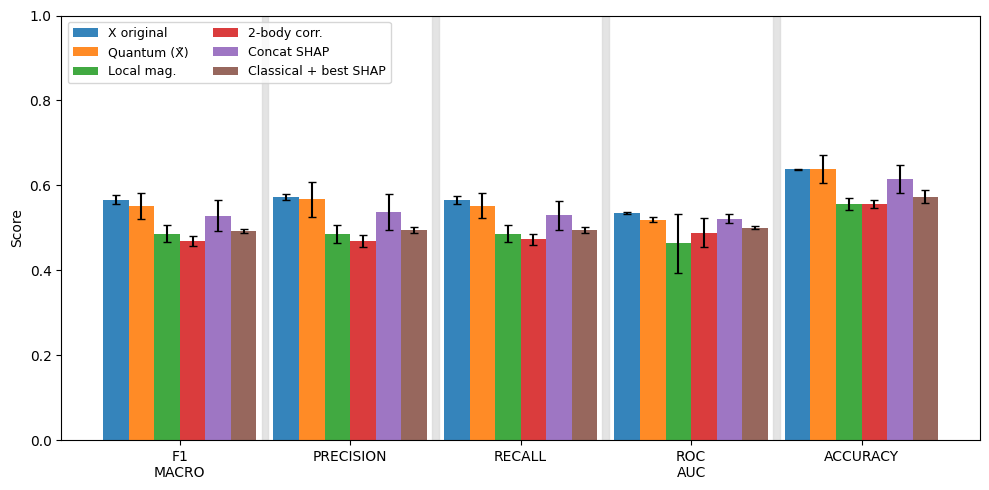

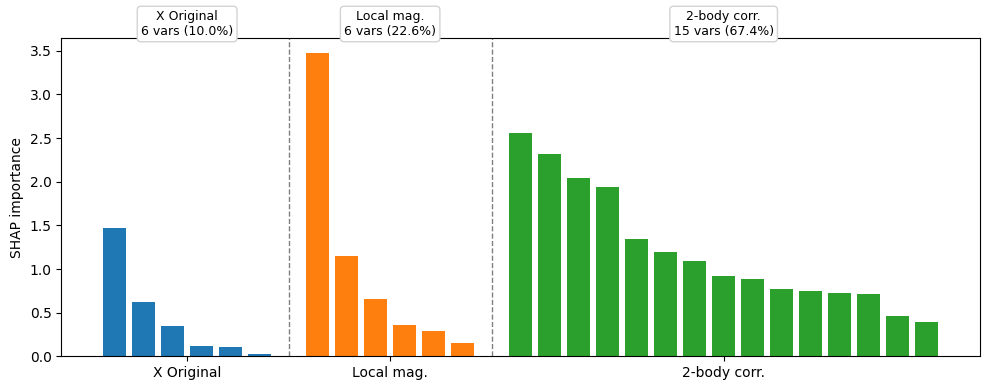

In [40]:
results = classification_quantum(X_reduced, y_raw, from_dir=FROM_DIR, k_max=K_MAX)
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)

Fold number: 1
Fold number: 2

=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.562 ± 0.024   0.568 ± 0.025  0.572 ± 0.034  0.593 ± 0.007  0.608 ± 0.004
Quantum (X̃)           0.500 ± 0.006   0.500 ± 0.006  0.500 ± 0.006  0.537 ± 0.019  0.550 ± 0.008
Quantum (k=1)          0.547 ± 0.009   0.549 ± 0.007  0.549 ± 0.011  0.556 ± 0.003  0.602 ± 0.009
Quantum (k=2)          0.522 ± 0.045   0.522 ± 0.045  0.522 ± 0.046  0.529 ± 0.039  0.573 ± 0.043
Quantum SHAP-k         0.548 ± 0.016   0.548 ± 0.016  0.549 ± 0.016  0.566 ± 0.001  0.597 ± 0.015
Classical + best SHAP  0.578 ± 0.017   0.593 ± 0.005  0.579 ± 0.015  0.596 ± 0.021  0.655 ± 0.004


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

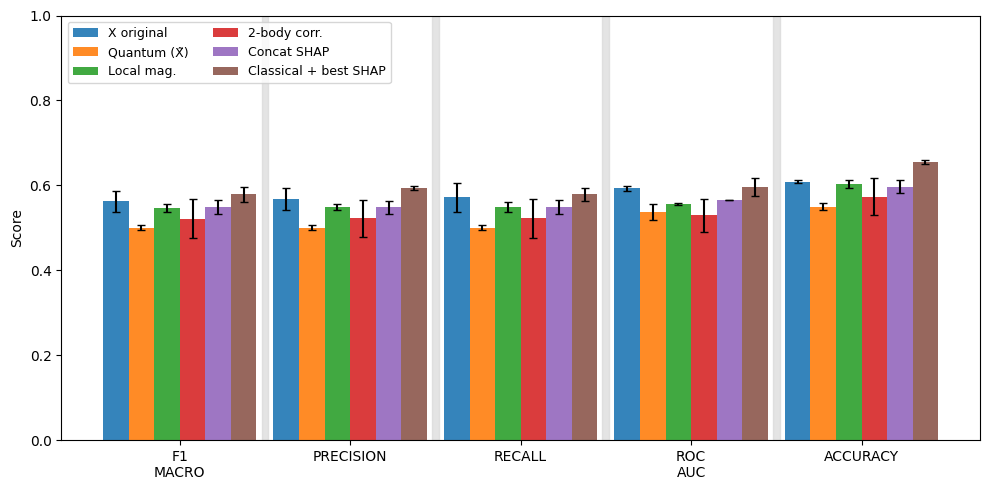

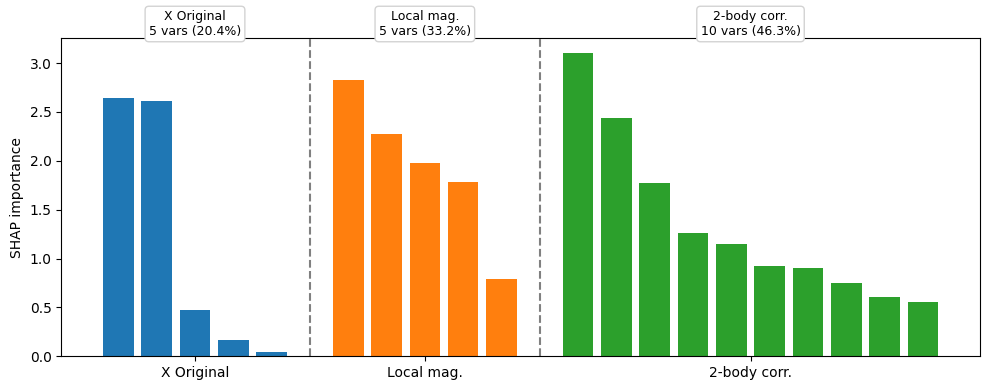

In [ ]:
results = classification_quantum(X_reduced, y_raw, from_dir=True)
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)

Previous tries

In [ ]:
results = classification_quantum_blocs(X_reduced, y_raw)


=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.462 ± 0.050   0.460 ± 0.055  0.481 ± 0.033  0.547 ± 0.040  0.585 ± 0.008
Quantum (X̃)           0.487 ± 0.001   0.492 ± 0.001  0.494 ± 0.001  0.515 ± 0.025  0.591 ± 0.002
Quantum (k=1)          0.523 ± 0.045   0.532 ± 0.042  0.530 ± 0.037  0.516 ± 0.007  0.620 ± 0.020
Quantum (k=2)          0.505 ± 0.035   0.508 ± 0.037  0.508 ± 0.032  0.511 ± 0.012  0.590 ± 0.026
Quantum SHAP-k         0.466 ± 0.015   0.467 ± 0.016  0.472 ± 0.012  0.513 ± 0.008  0.561 ± 0.003
Classical + best SHAP  0.530 ± 0.003   0.533 ± 0.001  0.530 ± 0.002  0.509 ± 0.012  0.602 ± 0.009


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

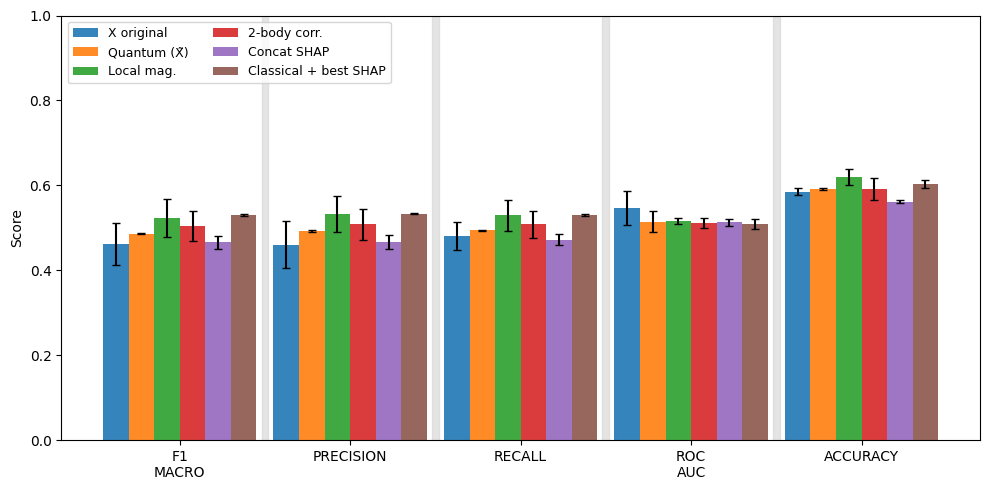

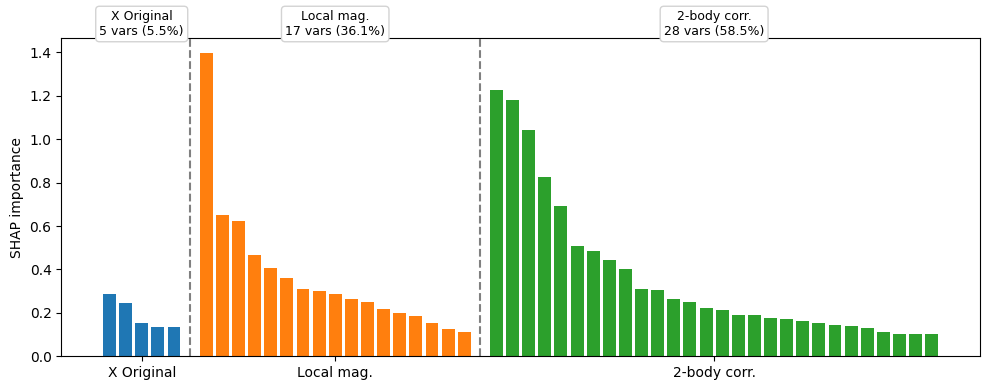

In [ ]:
# 150 gubits split into 15 blocks => 10 qubits per block, fakevigo
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)

In [ ]:
run_augmentation(X_reduced, y_raw, save_dir=DIR_PATH)

Fold number: 1


qmap: 100%|██████████| 86/86 [00:08<00:00, 10.48it/s]


Fold number: 2


qmap: 100%|██████████| 85/85 [00:08<00:00,  9.74it/s]


Fold number: 3


...

Fold number: 5


qmap: 100%|██████████| 86/86 [00:08<00:00, 10.40it/s]


Fold number: 6


qmap: 100%|██████████| 85/85 [00:07<00:00, 10.73it/s]

 Quantum features saved in: C:/Users/jiriv/Documents/škola/Diplom_thesis/Quantum-feature-maps/QFM_approach/results/test_errors


In [ ]:
results = classification_quantum(X_reduced, y_raw)

Fold number: 1
Fold number: 2
Fold number: 3
Fold number: 4
Fold number: 5
Fold number: 6



=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.610 ± 0.037   0.612 ± 0.035  0.621 ± 0.038  0.658 ± 0.036  0.661 ± 0.031
Quantum (X̃)           0.498 ± 0.017   0.501 ± 0.016  0.501 ± 0.015  0.536 ± 0.031  0.567 ± 0.023
Quantum (k=1)          0.588 ± 0.033   0.590 ± 0.032  0.587 ± 0.033  0.581 ± 0.035  0.637 ± 0.021
Quantum (k=2)          0.504 ± 0.066   0.510 ± 0.067  0.507 ± 0.065  0.536 ± 0.081  0.576 ± 0.066
Quantum SHAP-k         0.490 ± 0.028   0.499 ± 0.029  0.497 ± 0.028  0.538 ± 0.039  0.567 ± 0.040
Classical + best SHAP  0.515 ± 0.061   0.516 ± 0.064  0.517 ± 0.058  0.531 ± 0.069  0.585 ± 0.068


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

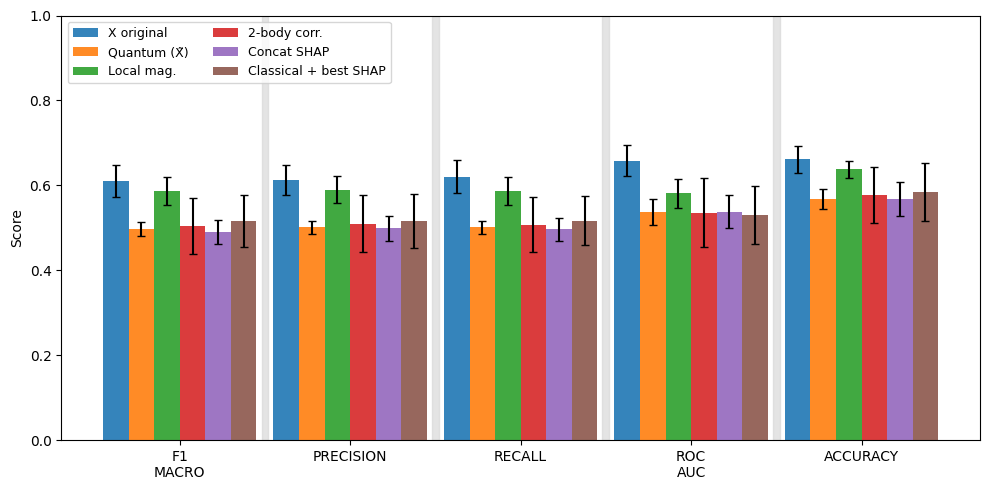

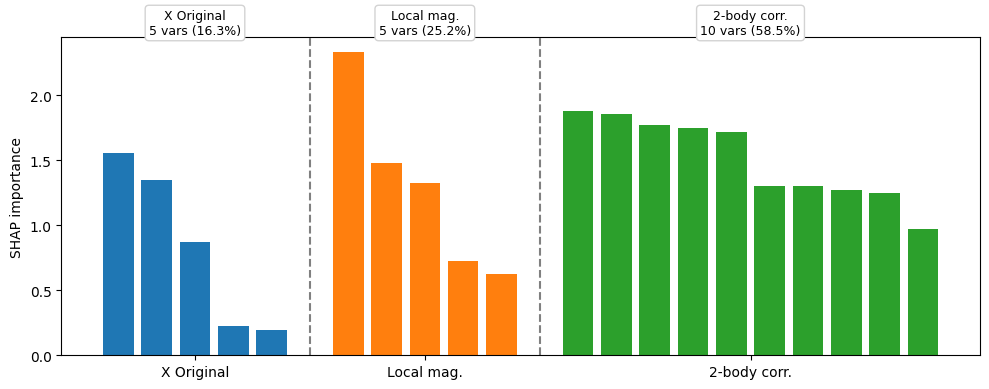

In [ ]:
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)

improved blocks

In [ ]:
results = classification_quantum_blocs(X_reduced, y_raw)


=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.513 ± 0.066   0.513 ± 0.077  0.513 ± 0.061  0.537 ± 0.076  0.596 ± 0.056
Quantum (X̃)           0.457 ± 0.047   0.462 ± 0.060  0.474 ± 0.040  0.510 ± 0.063  0.579 ± 0.040
Quantum (k=1)          0.526 ± 0.079   0.526 ± 0.092  0.526 ± 0.070  0.556 ± 0.058  0.649 ± 0.066
Quantum (k=2)          0.510 ± 0.043   0.516 ± 0.071  0.513 ± 0.042  0.526 ± 0.077  0.614 ± 0.051
Quantum SHAP-k         0.490 ± 0.048   0.524 ± 0.053  0.513 ± 0.043  0.536 ± 0.072  0.632 ± 0.041
Classical + best SHAP  0.499 ± 0.069   0.500 ± 0.080  0.500 ± 0.062  0.540 ± 0.056  0.579 ± 0.057


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

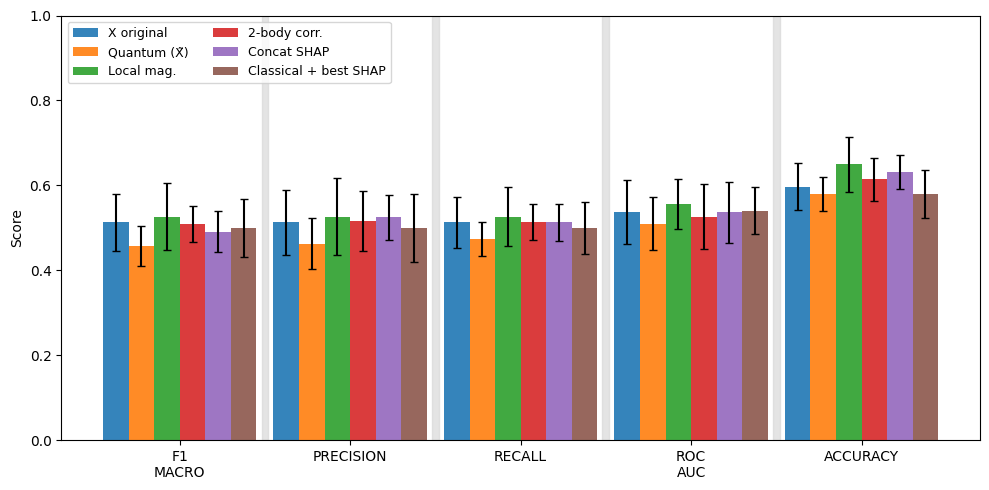

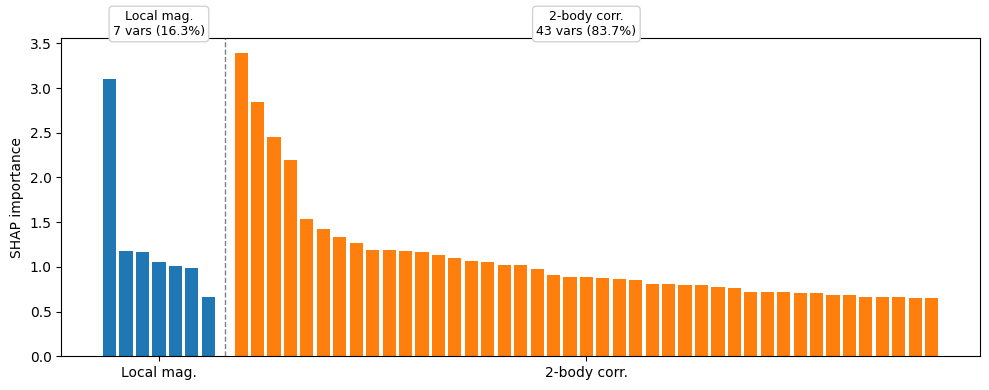

In [152]:
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)


=== Classification performance (median ± std over CV) ===

                         F1 Macro    Precision Macro  Recall Macro       AUC          Accuracy   
Model                                                                                            
Classical (X)          0.520 ± 0.023   0.548 ± 0.051  0.526 ± 0.029  0.547 ± 0.030  0.614 ± 0.056
Quantum (X̃)           0.517 ± 0.067   0.565 ± 0.111  0.529 ± 0.061  0.578 ± 0.091  0.644 ± 0.062
Quantum (k=1)          0.463 ± 0.001   0.469 ± 0.005  0.476 ± 0.007  0.510 ± 0.019  0.579 ± 0.021
Quantum (k=2)          0.565 ± 0.036   0.590 ± 0.053  0.565 ± 0.034  0.611 ± 0.073  0.655 ± 0.039
Quantum SHAP-k         0.516 ± 0.035   0.558 ± 0.066  0.529 ± 0.034  0.563 ± 0.096  0.644 ± 0.039
Classical + best SHAP  0.513 ± 0.049   0.526 ± 0.062  0.517 ± 0.047  0.493 ± 0.072  0.608 ± 0.050


(<Figure size 1000x400 with 1 Axes>, <Axes: ylabel='SHAP importance'>)

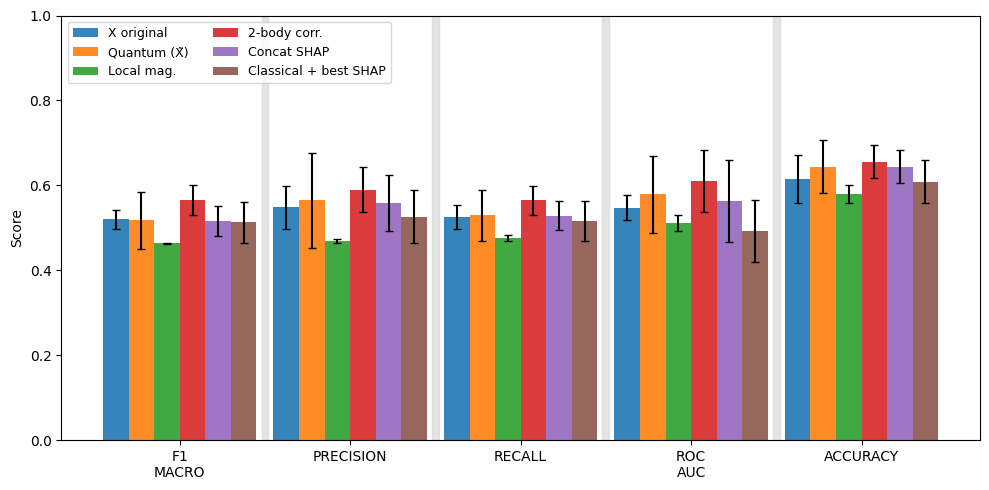

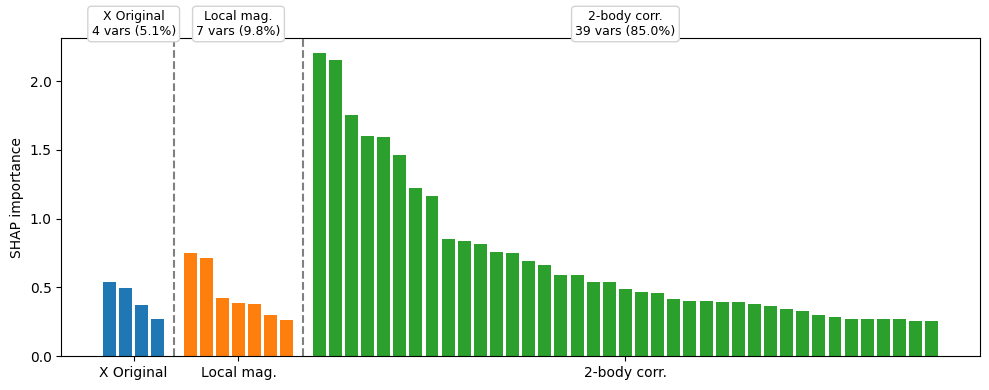

In [145]:
print_metrics_summary(results)
plot_quantum_performance(results)
plot_shap_grouped_importance(results)